In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('../__datasets__/placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
963,6.74,8.0,0
856,7.52,6.0,1
614,8.05,41.0,0
804,6.49,81.0,0
842,7.33,14.0,1


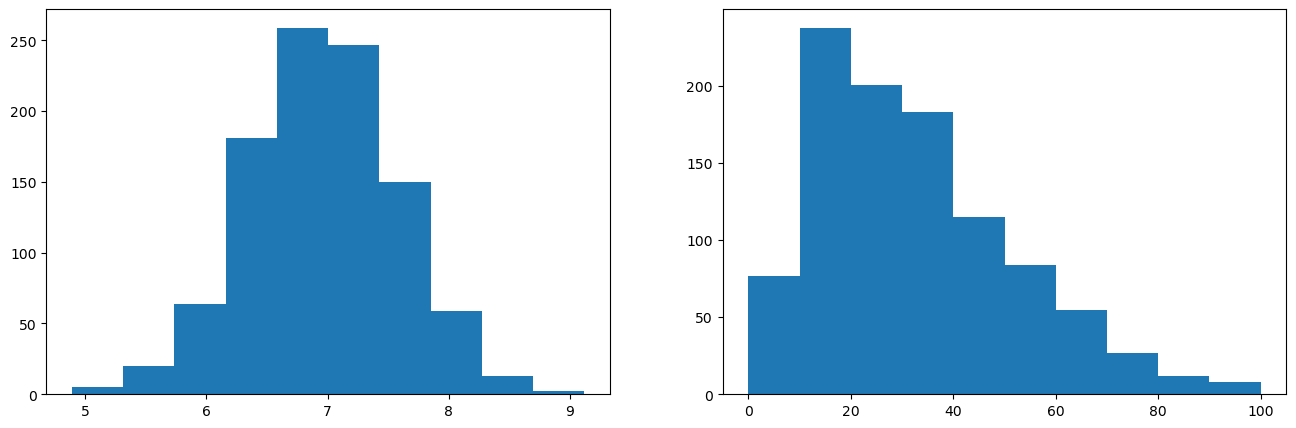

In [14]:
plt.figure(figsize=(16, 5))

plt.subplot(1,2,1)
plt.hist(df['cgpa'])

plt.subplot(1,2,2)
plt.hist(df['placement_exam_marks'])
plt.show()

In [17]:
print("Mean : ", df['cgpa'].mean())
print("Stdev : ", df['cgpa'].std())
print("median : ", df['cgpa'].median())
print("max : ", df['cgpa'].max())
print("min : ", df['cgpa'].min())

Mean :  6.96124
Stdev :  0.6158978751323894
median :  6.96
max :  9.12
min :  4.89


In [18]:
print("Highest allowed : ", df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed : ", df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed :  8.808933625397168
Lowest allowed :  5.113546374602832


In [21]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [24]:
new_df = df[(df['cgpa'] > 5.11) & (df['cgpa'] < 8.80)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [25]:
# 2nd approach Z-Score

df['cgpa_z_score'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df

,cgpa,placement_exam_marks,placed,cgpa_z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [26]:
df[(df['cgpa_z_score'] > 3) | (df['cgpa_z_score'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [28]:
#trimming
new_df2 = df[(df['cgpa_z_score'] < 3) & (df['cgpa_z_score'] > -3)]
new_df2

,cgpa,placement_exam_marks,placed,cgpa_z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping

In [37]:
upper_lim = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_lim = df['cgpa'].mean() - 3*df['cgpa'].std()
print(f"(Q1 : {lower_lim}), (Q2 : {df['cgpa'].median()}), (Q3 : {upper_lim})")

(Q1 : 5.113546374602832), (Q2 : 6.96), (Q3 : 8.808933625397168)


In [38]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_lim, # condition
    upper_lim,              # true 
    np.where(               # else
        df['cgpa'] > lower_lim, # condition
        df['cgpa'],             # true
        lower_lim               # else
    )
)

In [39]:
df[(df['cgpa'] < lower_lim) | (df['cgpa'] > upper_lim)]   # all outliers replaced with boundaries

,cgpa,placement_exam_marks,placed,cgpa_z_score


In [40]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64